## Part 1 - Data Preparation and Exploration 

In [1]:
#Import Libraries

import pandas as pd
import datetime as dt
import scipy.stats as sp
import numpy as np
import statsmodels.formula.api as sm 

In [2]:
# Import Shotlog_14_15 and Player_Stats Datasets

Shotlog_1415=pd.read_csv("Shotlog_14_15.csv")
Player_Stats=pd.read_csv("Player_Stats_14_15.csv")
Shotlog_1415.head(3)

,game_id,date,match,home_team,away_team,home_away,result,final_margin,shot_number,quarter,...,closest_defender,closest_defender_id,closest_def_dist,current_shot_hit,points_earned,shoot_player,player_id,average_hit,shot_count,shot_per_game
0,21400280,5-Dec-14,ATL @ BKN,BKN,ATL,A,W,23,1,1,...,"Lopez, Brook",201572,6.6,1,2,al horford,201143,0.541259,715,10
1,21400280,5-Dec-14,ATL @ BKN,BKN,ATL,A,W,23,2,1,...,"Lopez, Brook",201572,5.6,0,0,al horford,201143,0.541259,715,10
2,21400280,5-Dec-14,ATL @ BKN,BKN,ATL,A,W,23,3,1,...,"Lopez, Brook",201572,4.7,0,0,al horford,201143,0.541259,715,10


In [3]:
Shotlog_1415.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128069 entries, 0 to 128068
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   game_id               128069 non-null  int64  
 1   date                  128069 non-null  object 
 2   match                 128069 non-null  object 
 3   home_team             128069 non-null  object 
 4   away_team             128069 non-null  object 
 5   home_away             128069 non-null  object 
 6   result                128069 non-null  object 
 7   final_margin          128069 non-null  int64  
 8   shot_number           128069 non-null  int64  
 9   quarter               128069 non-null  int64  
 10  game_clock            128069 non-null  object 
 11  shot_clock            122502 non-null  float64
 12  dribbles              128069 non-null  int64  
 13  touch_time            128069 non-null  float64
 14  shot_dist             128069 non-null  float64
 15  

In [4]:
len(Shotlog_1415.game_id.unique())

904

In [5]:
len(Shotlog_1415.player_id.unique())

281

In [6]:
Shotlog_1415['date'] = pd.to_datetime(Shotlog_1415.date)
Shotlog_1415.date.dtype

dtype('<M8[ns]')

In [7]:
Shotlog_1415.columns

Index(['game_id', 'date', 'match', 'home_team', 'away_team', 'home_away',
       'result', 'final_margin', 'shot_number', 'quarter', 'game_clock',
       'shot_clock', 'dribbles', 'touch_time', 'shot_dist', 'points',
       'current_shot_outcome', 'closest_defender', 'closest_defender_id',
       'closest_def_dist', 'current_shot_hit', 'points_earned', 'shoot_player',
       'player_id', 'average_hit', 'shot_count', 'shot_per_game'],
      dtype='object')

In [8]:
Shotlog_1415['shot_clock'] = pd.to_timedelta(Shotlog_1415.shot_clock)
Shotlog_1415.shot_clock.describe()

count                       122502
mean     0 days 00:00:00.000000012
std      0 days 00:00:00.000000005
min                0 days 00:00:00
25%      0 days 00:00:00.000000008
50%      0 days 00:00:00.000000012
75%      0 days 00:00:00.000000016
max      0 days 00:00:00.000000024
Name: shot_clock, dtype: object

In [9]:
Shotlog_1415['lag_shot_hit'] = Shotlog_1415.sort_values(by=['quarter', 'game_clock'], \
                                                        ascending = [True, True]) \
                                                        .groupby(['shot_number', 'game_id']) \
                                                        ['current_shot_hit'].shift(1)

In [10]:
Shotlog_1415.head(3)

,game_id,date,match,home_team,away_team,home_away,result,final_margin,shot_number,quarter,...,closest_defender_id,closest_def_dist,current_shot_hit,points_earned,shoot_player,player_id,average_hit,shot_count,shot_per_game,lag_shot_hit
0,21400280,2014-12-05,ATL @ BKN,BKN,ATL,A,W,23,1,1,...,201572,6.6,1,2,al horford,201143,0.541259,715,10,1.0
1,21400280,2014-12-05,ATL @ BKN,BKN,ATL,A,W,23,2,1,...,201572,5.6,0,0,al horford,201143,0.541259,715,10,0.0
2,21400280,2014-12-05,ATL @ BKN,BKN,ATL,A,W,23,3,1,...,201572,4.7,0,0,al horford,201143,0.541259,715,10,1.0


In [11]:
Shotlog_1415.sort_values(by=['shot_number','game_id', 'quarter', 'game_clock'],
                         ascending=[True, True, True, True]).head(5)

,game_id,date,match,home_team,away_team,home_away,result,final_margin,shot_number,quarter,...,closest_defender_id,closest_def_dist,current_shot_hit,points_earned,shoot_player,player_id,average_hit,shot_count,shot_per_game,lag_shot_hit
81555,21400001,2014-10-28,NOP vs. ORL,NOP,ORL,H,W,17,1,1,...,202696,1.7,1,2,omer asik,201600,0.506667,300,10,NaN
94499,21400001,2014-10-28,ORL @ NOP,NOP,ORL,A,L,-17,1,1,...,201950,2.0,0,0,elfrid payton,203901,0.412500,480,8,1.0
95317,21400001,2014-10-28,ORL @ NOP,NOP,ORL,A,L,-17,1,1,...,201600,6.5,1,2,nikola vucevic,202696,0.532151,902,15,0.0
84394,21400001,2014-10-28,NOP vs. ORL,NOP,ORL,H,W,17,1,1,...,203124,4.6,0,0,anthony davis,203076,0.543401,841,22,1.0
84644,21400001,2014-10-28,NOP vs. ORL,NOP,ORL,H,W,17,1,1,...,2732,4.4,0,0,jimmer dredette,202690,0.384106,151,6,0.0


In [12]:
Shotlog_1415['error'] = Shotlog_1415.current_shot_hit - Shotlog_1415.average_hit
Shotlog_1415['lagerror'] = Shotlog_1415.lag_shot_hit - Shotlog_1415.average_hit
Shotlog_1415.head(3)

,game_id,date,match,home_team,away_team,home_away,result,final_margin,shot_number,quarter,...,current_shot_hit,points_earned,shoot_player,player_id,average_hit,shot_count,shot_per_game,lag_shot_hit,error,lagerror
0,21400280,2014-12-05,ATL @ BKN,BKN,ATL,A,W,23,1,1,...,1,2,al horford,201143,0.541259,715,10,1.0,0.458741,0.458741
1,21400280,2014-12-05,ATL @ BKN,BKN,ATL,A,W,23,2,1,...,0,0,al horford,201143,0.541259,715,10,0.0,-0.541259,-0.541259
2,21400280,2014-12-05,ATL @ BKN,BKN,ATL,A,W,23,3,1,...,0,0,al horford,201143,0.541259,715,10,1.0,-0.541259,0.458741


In [13]:
#pd.set_option('display.float_format', lambda x: '%.3f' % x)
Shotlog_1415.error.describe().round(3)

count    128069.000
mean          0.000
std           0.495
min          -0.712
25%          -0.449
50%          -0.385
75%           0.540
max           0.691
Name: error, dtype: float64

In [14]:
Shotlog_1415.lagerror.describe().round(3)

count    110484.000
mean          0.001
std           0.501
min          -0.712
25%          -0.450
50%          -0.386
75%           0.550
max           0.691
Name: lagerror, dtype: float64

## Part 2 - Conditional Probability and Autocorrelation

Create a dummy variable “conse_shot” that indicates a player made consecutive shots. 

In [15]:
Shotlog_1415['conse_shot'] = np.where((Shotlog_1415.current_shot_hit==1)&(Shotlog_1415.lag_shot_hit==1), 1, 0)
Shotlog_1415.head(3)

,game_id,date,match,home_team,away_team,home_away,result,final_margin,shot_number,quarter,...,points_earned,shoot_player,player_id,average_hit,shot_count,shot_per_game,lag_shot_hit,error,lagerror,conse_shot
0,21400280,2014-12-05,ATL @ BKN,BKN,ATL,A,W,23,1,1,...,2,al horford,201143,0.541259,715,10,1.0,0.458741,0.458741,1
1,21400280,2014-12-05,ATL @ BKN,BKN,ATL,A,W,23,2,1,...,0,al horford,201143,0.541259,715,10,0.0,-0.541259,-0.541259,0
2,21400280,2014-12-05,ATL @ BKN,BKN,ATL,A,W,23,3,1,...,0,al horford,201143,0.541259,715,10,1.0,-0.541259,0.458741,0


Create a dataframe “Player_Prob” for the probability of making the previous shot and the joint probability for making both the previous and current shots. Name the probability of making the previous shot “average_lag_hit” and the probability of making both shots “conse_shot_hit.” 

In [16]:
Player_Prob = Shotlog_1415.groupby(['shoot_player'])['conse_shot','lag_shot_hit'].mean()
Player_Prob = Player_Prob.reset_index()
Player_Prob.rename(columns={'conse_shot':'conse_shot_hit',
                           'lag_shot_hit':'average_lag_hit'}, inplace=True)
Player_Prob

/tmp/ipykernel_23937/3694260147.py:1: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  Player_Prob = Shotlog_1415.groupby(['shoot_player'])['conse_shot','lag_shot_hit'].mean()


,shoot_player,conse_shot_hit,average_lag_hit
0,aaron brooks,0.183601,0.442085
1,aaron gordon,0.240385,0.425743
2,al farouq aminu,0.205426,0.487805
3,al horford,0.206993,0.454254
4,al jefferson,0.155000,0.425926
...,...,...,...
276,wesley matthews,0.200535,0.478134
277,wilson chandler,0.130969,0.414430
278,zach lavine,0.159030,0.451705
279,zach randolph,0.187779,0.460377


In [ ]:
Player_Prob['conditional_prob'] = Player_Prob.conse_shot_hit/ \
                                  Player_Prob.average_lag_hit
Player_Prob.head()

In [18]:
Player_Prob.conditional_prob.describe()

count    281.000000
mean       0.405023
std        0.076769
min        0.206847
25%        0.359278
50%        0.396747
75%        0.444444
max        0.680920
Name: conditional_prob, dtype: float64

In [19]:
Player_Stats = pd.merge(Player_Prob, Player_Stats, on=['shoot_player'])
Player_Stats.head(3)

,shoot_player,conse_shot_hit,average_lag_hit,conditional_prob,average_hit
0,aaron brooks,0.183601,0.442085,0.415306,0.415330
1,aaron gordon,0.240385,0.425743,0.564624,0.528846
2,al farouq aminu,0.205426,0.487805,0.421124,0.430233


In [20]:
Player_Stats.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 281 entries, 0 to 280
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   shoot_player      281 non-null    object 
 1   conse_shot_hit    281 non-null    float64
 2   average_lag_hit   281 non-null    float64
 3   conditional_prob  281 non-null    float64
 4   average_hit       281 non-null    float64
dtypes: float64(4), object(1)
memory usage: 13.2+ KB


In [21]:
import scipy.stats as sp

In [22]:
sp.stats.ttest_ind(Player_Stats.conditional_prob, Player_Stats.average_hit)

Ttest_indResult(statistic=-8.034602063592851, pvalue=5.583377754496397e-15)

In [23]:
Shotlog_1415.current_shot_hit.corr(Shotlog_1415.lag_shot_hit)

-0.0025184251359644046

In [24]:
Autocorr_Log = Shotlog_1415.groupby('shoot_player')\
                [['current_shot_hit','lag_shot_hit']].corr().unstack()
Autocorr_Log.head(10)

current_shot_hit                  lag_shot_hit             
                current_shot_hit lag_shot_hit current_shot_hit lag_shot_hit
shoot_player                                                               
aaron brooks                 1.0     0.027690         0.027690          1.0
aaron gordon                 1.0     0.097663         0.097663          1.0
al farouq aminu              1.0     0.029275         0.029275          1.0
al horford                   1.0    -0.041738        -0.041738          1.0
al jefferson                 1.0     0.032333         0.032333          1.0
alan anderson                1.0     0.078539         0.078539          1.0
alan crabbe                  1.0    -0.148148        -0.148148          1.0
alex len                     1.0     0.017817         0.017817          1.0
alexis ajinca                1.0     0.146881         0.146881          1.0
alonzo gee                   1.0     0.106202         0.106202          1.0

In [25]:
Autocorr_Hit=Shotlog_1415.groupby('shoot_player')\
            [['current_shot_hit','lag_shot_hit']].corr().unstack().iloc[:,1].reset_index()
Autocorr_Hit.head()

,shoot_player,current_shot_hit
,,lag_shot_hit
0,aaron brooks,0.027690
1,aaron gordon,0.097663
2,al farouq aminu,0.029275
3,al horford,-0.041738
4,al jefferson,0.032333


In [26]:
Autocorr_Hit.columns=Autocorr_Hit.columns.get_level_values(0)
Autocorr_Hit.head()

,shoot_player,current_shot_hit
0,aaron brooks,0.027690
1,aaron gordon,0.097663
2,al farouq aminu,0.029275
3,al horford,-0.041738
4,al jefferson,0.032333


In [27]:
Autocorr_Hit.rename(columns={'current_shot_hit':'autocorr'}, inplace=True)
Autocorr_Hit.head()

,shoot_player,autocorr
0,aaron brooks,0.027690
1,aaron gordon,0.097663
2,al farouq aminu,0.029275
3,al horford,-0.041738
4,al jefferson,0.032333


In [28]:
Autocorr_Hit.sort_values(by=['autocorr'], ascending=[False]).head(5)

,shoot_player,autocorr
235,rudy gobert,0.164823
8,alexis ajinca,0.146881
65,david west,0.130245
27,bismack biyombo,0.119737
211,omer asik,0.111122


## Part 3 - Regression Analyses

In [29]:
Shotlog_1415.head()

,game_id,date,match,home_team,away_team,home_away,result,final_margin,shot_number,quarter,...,points_earned,shoot_player,player_id,average_hit,shot_count,shot_per_game,lag_shot_hit,error,lagerror,conse_shot
0,21400280,2014-12-05,ATL @ BKN,BKN,ATL,A,W,23,1,1,...,2,al horford,201143,0.541259,715,10,1.0,0.458741,0.458741,1
1,21400280,2014-12-05,ATL @ BKN,BKN,ATL,A,W,23,2,1,...,0,al horford,201143,0.541259,715,10,0.0,-0.541259,-0.541259,0
2,21400280,2014-12-05,ATL @ BKN,BKN,ATL,A,W,23,3,1,...,0,al horford,201143,0.541259,715,10,1.0,-0.541259,0.458741,0
3,21400280,2014-12-05,ATL @ BKN,BKN,ATL,A,W,23,4,1,...,0,al horford,201143,0.541259,715,10,1.0,-0.541259,0.458741,0
4,21400280,2014-12-05,ATL @ BKN,BKN,ATL,A,W,23,5,2,...,0,al horford,201143,0.541259,715,10,1.0,-0.541259,0.458741,0


In [30]:
Shotlog_1415['error'] = Shotlog_1415.current_shot_hit - \
                        Shotlog_1415.average_hit

Shotlog_1415['lagerror'] = Shotlog_1415.lag_shot_hit - \
                            Shotlog_1415.average_hit

In [31]:
Shotlog_1415.game_clock

0         11:23
1         10:48
2          9:40
3          7:09
4          5:49
          ...  
128064     2:59
128065     0:43
128066     2:18
128067     2:18
128068     1:40
Name: game_clock, Length: 128069, dtype: object

In [32]:
Shotlog_1415['game_clock'] = pd.to_timedelta('00:'+Shotlog_1415['game_clock'])

In [33]:
Shotlog_1415.loc[Shotlog_1415.shoot_player == 'lebron james'].head()

,game_id,date,match,home_team,away_team,home_away,result,final_margin,shot_number,quarter,...,points_earned,shoot_player,player_id,average_hit,shot_count,shot_per_game,lag_shot_hit,error,lagerror,conse_shot
27320,21400303,2014-12-08,CLE @ BKN,BKN,CLE,A,W,22,1,1,...,3,lebron james,2544,0.488753,978,17,0.0,0.511247,-0.488753,0
27321,21400303,2014-12-08,CLE @ BKN,BKN,CLE,A,W,22,2,1,...,0,lebron james,2544,0.488753,978,17,0.0,-0.488753,-0.488753,0
27322,21400303,2014-12-08,CLE @ BKN,BKN,CLE,A,W,22,3,1,...,0,lebron james,2544,0.488753,978,17,0.0,-0.488753,-0.488753,0
27323,21400303,2014-12-08,CLE @ BKN,BKN,CLE,A,W,22,4,1,...,0,lebron james,2544,0.488753,978,17,0.0,-0.488753,-0.488753,0
27324,21400303,2014-12-08,CLE @ BKN,BKN,CLE,A,W,22,5,1,...,2,lebron james,2544,0.488753,978,17,0.0,0.511247,-0.488753,0


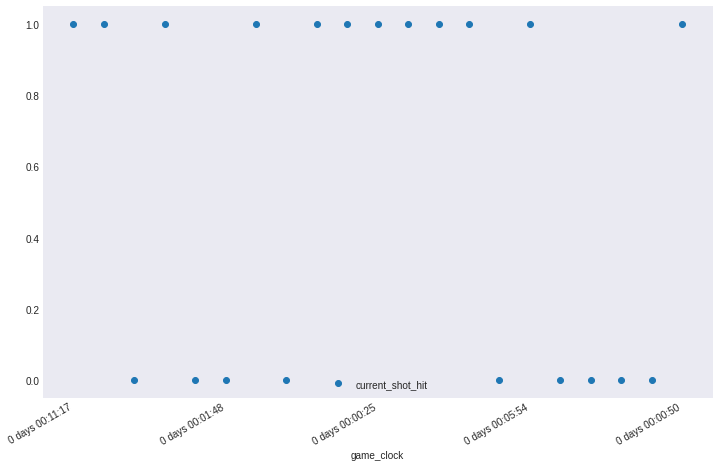

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 8)
plt.style.use('seaborn-dark')

LeBron_James = Shotlog_1415[(Shotlog_1415.shoot_player == 'lebron james') \
             &(Shotlog_1415.date == '2014-12-09')] \
            .plot(x='game_clock', y = 'current_shot_hit', \
            marker = 'o', linewidth=0)

In [35]:
Shotlog_1415.columns

Index(['game_id', 'date', 'match', 'home_team', 'away_team', 'home_away',
       'result', 'final_margin', 'shot_number', 'quarter', 'game_clock',
       'shot_clock', 'dribbles', 'touch_time', 'shot_dist', 'points',
       'current_shot_outcome', 'closest_defender', 'closest_defender_id',
       'closest_def_dist', 'current_shot_hit', 'points_earned', 'shoot_player',
       'player_id', 'average_hit', 'shot_count', 'shot_per_game',
       'lag_shot_hit', 'error', 'lagerror', 'conse_shot'],
      dtype='object')

In [36]:
Shotlog_1415.home_away

0         A
1         A
2         A
3         A
4         A
         ..
128064    H
128065    H
128066    H
128067    H
128068    H
Name: home_away, Length: 128069, dtype: object

In [37]:
r1 = 'error ~ shot_dist + dribbles + touch_time + '
r2 = 'points + C(quarter) + home_away + shoot_player + '
r3 = 'closest_defender_id + closest_def_dist'
reg_formula = r1 + r2 + r3
reg1 = sm.ols(formula = reg_formula, data=Shotlog_1415).fit()
print(reg1.summary())

                            OLS Regression Results                            
Dep. Variable:                  error   R-squared:                       0.048
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     22.22
Date:                Tue, 07 Dec 2021   Prob (F-statistic):               0.00
Time:                        21:02:42   Log-Likelihood:                -88473.
No. Observations:              128069   AIC:                         1.775e+05
Df Residuals:                  127775   BIC:                         1.804e+05
Df Model:                         293                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

In [40]:
reg2 = sm.wls(formula=reg_formula, 
              weights=1/Shotlog_1415.shot_per_game, 
              data=Shotlog_1415).fit()

In [41]:
print(reg2.summary())

                            WLS Regression Results                            
Dep. Variable:                  error   R-squared:                       0.052
Model:                            WLS   Adj. R-squared:                  0.049
Method:                 Least Squares   F-statistic:                     23.70
Date:                Tue, 07 Dec 2021   Prob (F-statistic):               0.00
Time:                        21:06:23   Log-Likelihood:            -1.0080e+05
No. Observations:              128069   AIC:                         2.022e+05
Df Residuals:                  127775   BIC:                         2.051e+05
Df Model:                         293                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

In [44]:
cols = print(list(Shotlog_1415.columns))

['game_id', 'date', 'match', 'home_team', 'away_team', 'home_away', 'result', 'final_margin', 'shot_number', 'quarter', 'game_clock', 'shot_clock', 'dribbles', 'touch_time', 'shot_dist', 'points', 'current_shot_outcome', 'closest_defender', 'closest_defender_id', 'closest_def_dist', 'current_shot_hit', 'points_earned', 'shoot_player', 'player_id', 'average_hit', 'shot_count', 'shot_per_game', 'lag_shot_hit', 'error', 'lagerror', 'conse_shot']


In [45]:
def reg_player(player):
    Shotlog_player = Shotlog_1415[Shotlog_1415.shoot_player == player]
    f1 = 'error ~ shot_dist + dribbles + touch_time + '
    f2 = 'points + C(quarter) + home_away + closest_defender'
    reg_player = sm.ols(formula=f1+f2,
                        data=Shotlog_1415).fit()
    print(reg_player.summary())
    return reg_player

In [53]:
def reg_wls_player(player):
    Shotlog_player=Shotlog_1415[Shotlog_1415.shoot_player==player]
    f1 = 'error ~ shot_dist + dribbles + touch_time + '
    f2 = 'points + C(quarter) + home_away + closest_defender'
    reg_wls_player = sm.wls(formula='error ~ shot_dist + dribbles + touch_time + points + C(quarter) + home_away + closest_defender',
                        weight=1/Shotlog_player.shot_per_game,
                        data=Shotlog_1415).fit()
    print(reg_wls_player.summary())
    return reg_wls_player

In [47]:
reg_player('lebron james')

                            OLS Regression Results                            
Dep. Variable:                  error   R-squared:                       0.037
Model:                            OLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     10.28
Date:                Tue, 07 Dec 2021   Prob (F-statistic):               0.00
Time:                        21:24:02   Log-Likelihood:                -89209.
No. Observations:              128069   AIC:                         1.794e+05
Df Residuals:                  127585   BIC:                         1.841e+05
Df Model:                         483                                         
Covariance Type:            nonrobust                                         
                                                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------

In [54]:
reg_wls_player('lebron james')

ValueError: operands could not be broadcast together with shapes (128069,1) (978,1) 